In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [4]:
# Generate Linear Data
np.random.seed(42)
n = 1000

# --- MCAR ---

# 1000 evenly spaced numbers from 0 to 100
x = np.linspace(0, 100, n)
# y = 2x + 5 + noise
y = 2 * x + 5 + np.random.normal(0, 10, n)
df1 = pd.DataFrame({'Feature_A': x, 'Feature_B': y})

# Punch holes (20% missing)
perc_missing = round(n  * 0.2)
df_miss_MCAR = df1.copy()
df_miss_MCAR.iloc[np.random.choice(n, perc_missing , replace=False), 1] = np.nan

missing_values_df_MCAR = missing_values_table(df_miss_MCAR)
missing_values_df_MCAR

Your selected dataframe has 2 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Feature_B,200,20.0


In [5]:
# --- MAR ---

# Generate observed variable
age = np.random.normal(40, 10, n)
# Generate target variable
income = 30000 + age * 1000 + np.random.normal(0, 5000, n)
df2 = pd.DataFrame({"Feature_A": age, "Feature_B": income})

# Create MAR missingness in Income depending on Age
prob_missing = 1 / (1 + np.exp(-(age - 50) / 5))
missing_mask = np.random.rand(n) < prob_missing
df_miss_MAR = df2.copy()
df_miss_MAR.loc[missing_mask, "Feature_B"] = np.nan

missing_values_df_MAR = missing_values_table(df_miss_MAR)
missing_values_df_MAR

Your selected dataframe has 2 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Feature_B,255,25.5


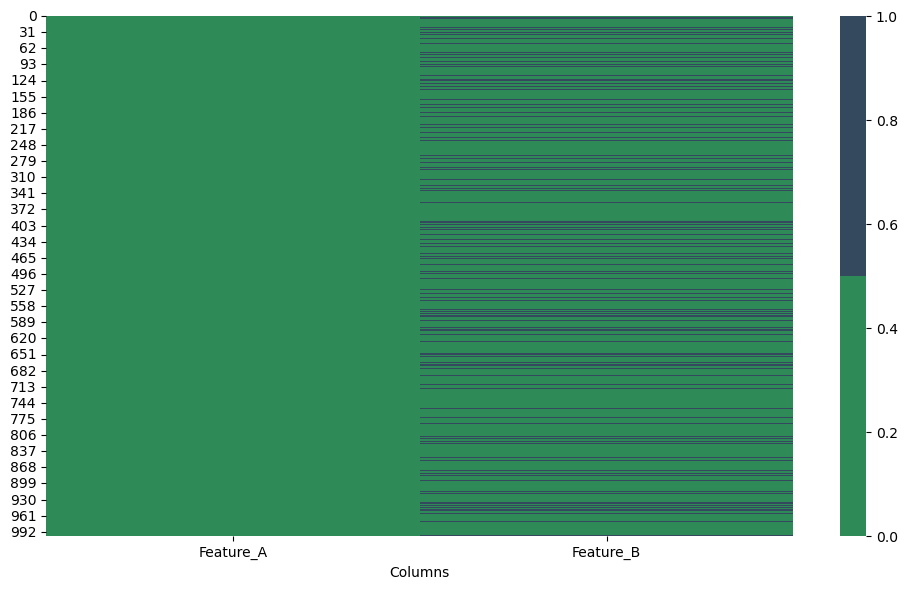

In [6]:
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
sns.heatmap(df_miss_MCAR.isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

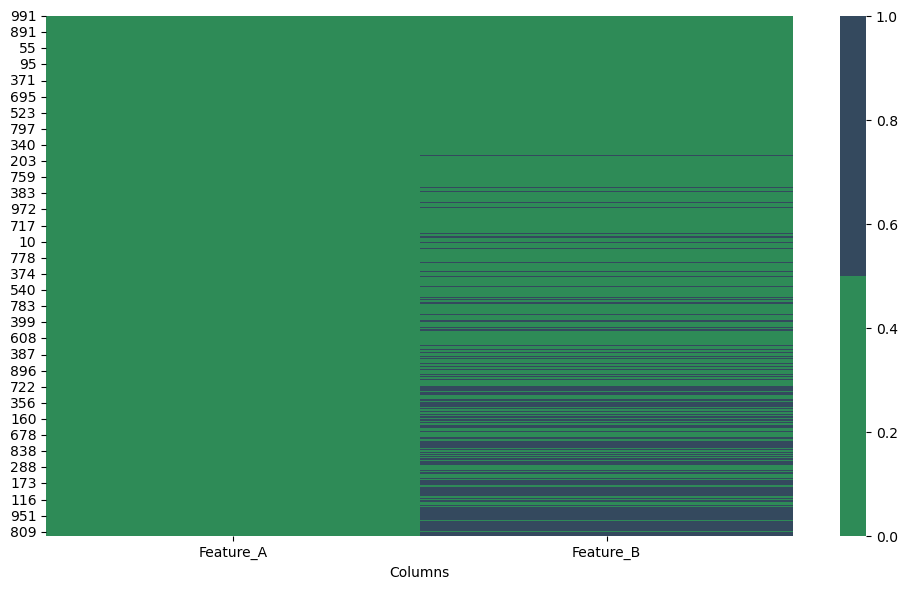

In [7]:
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
df_miss_MAR = df_miss_MAR.sort_values("Feature_A")
# in order to understand the MAR, it has to be in sorted order of a column that we suspect has impact on missing value
# if we do similarly to the MCAR, the missing values are still seen scattered
sns.heatmap(df_miss_MAR.isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

<Axes: >

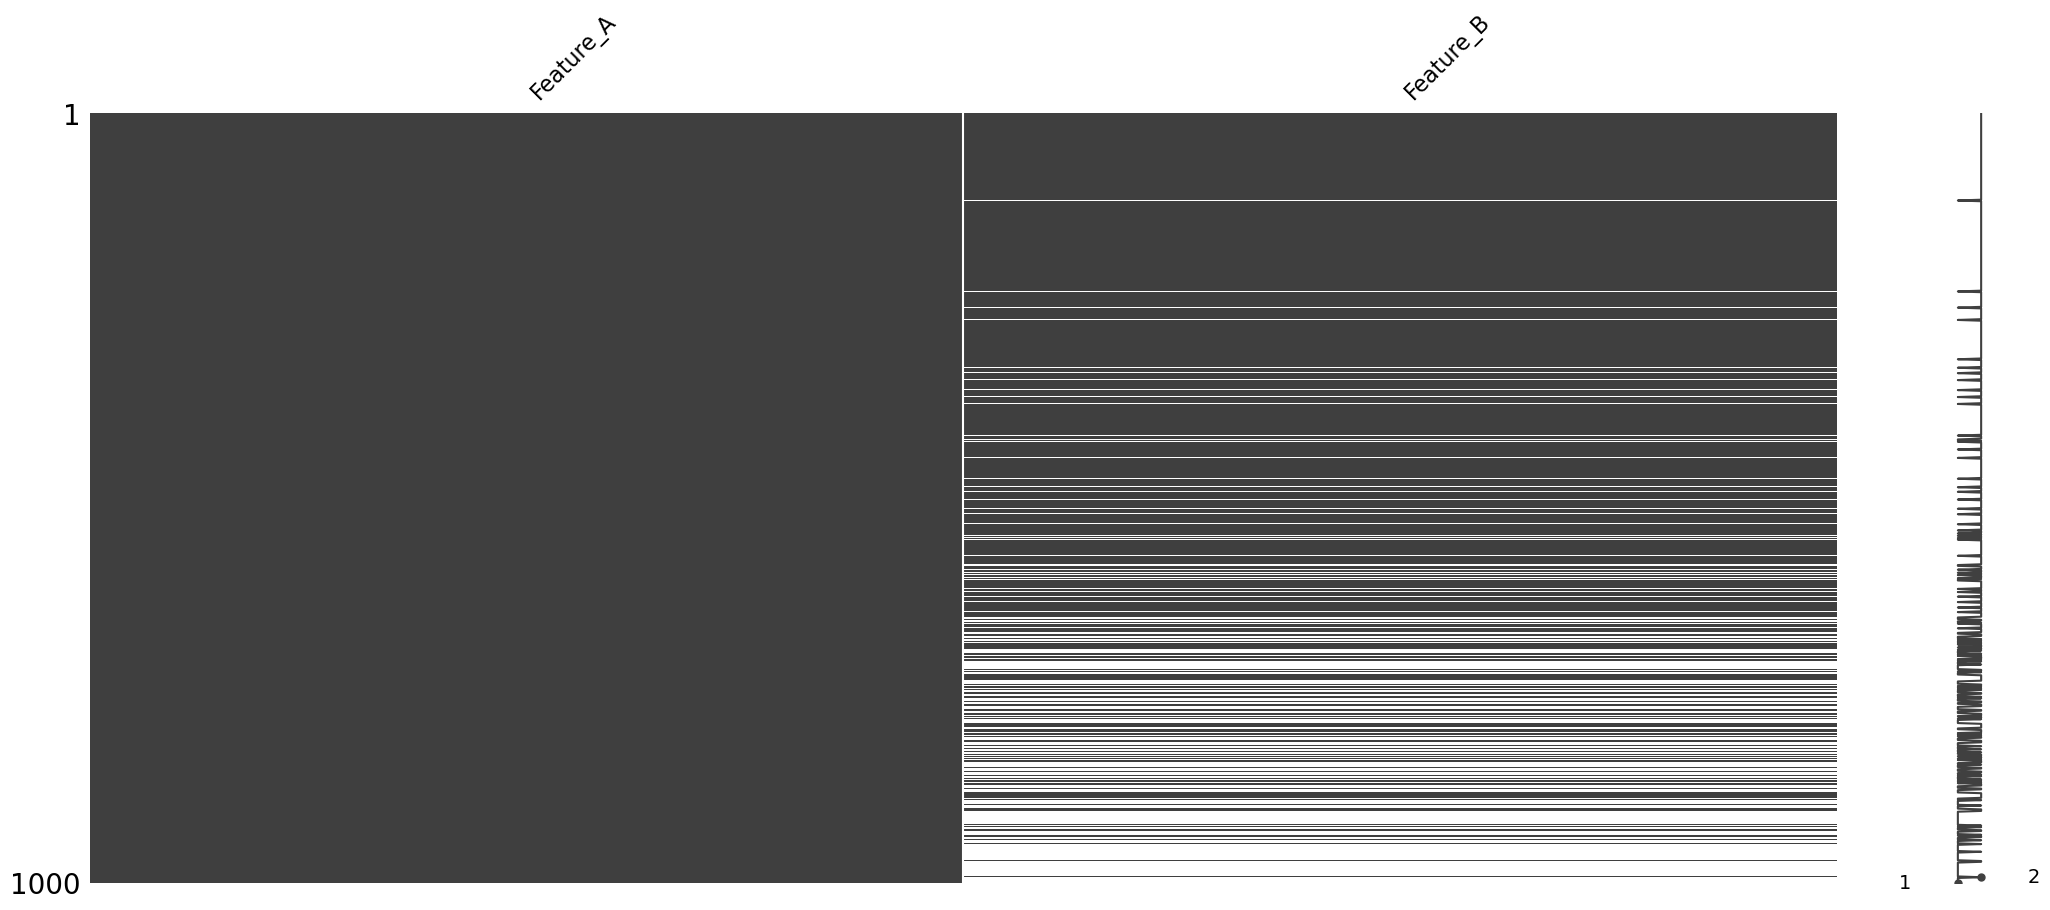

In [8]:
# missingno library produces the same results
df_miss_MAR = df_miss_MAR.sort_values("Feature_A")
msno.matrix(df_miss_MAR)

<Axes: >

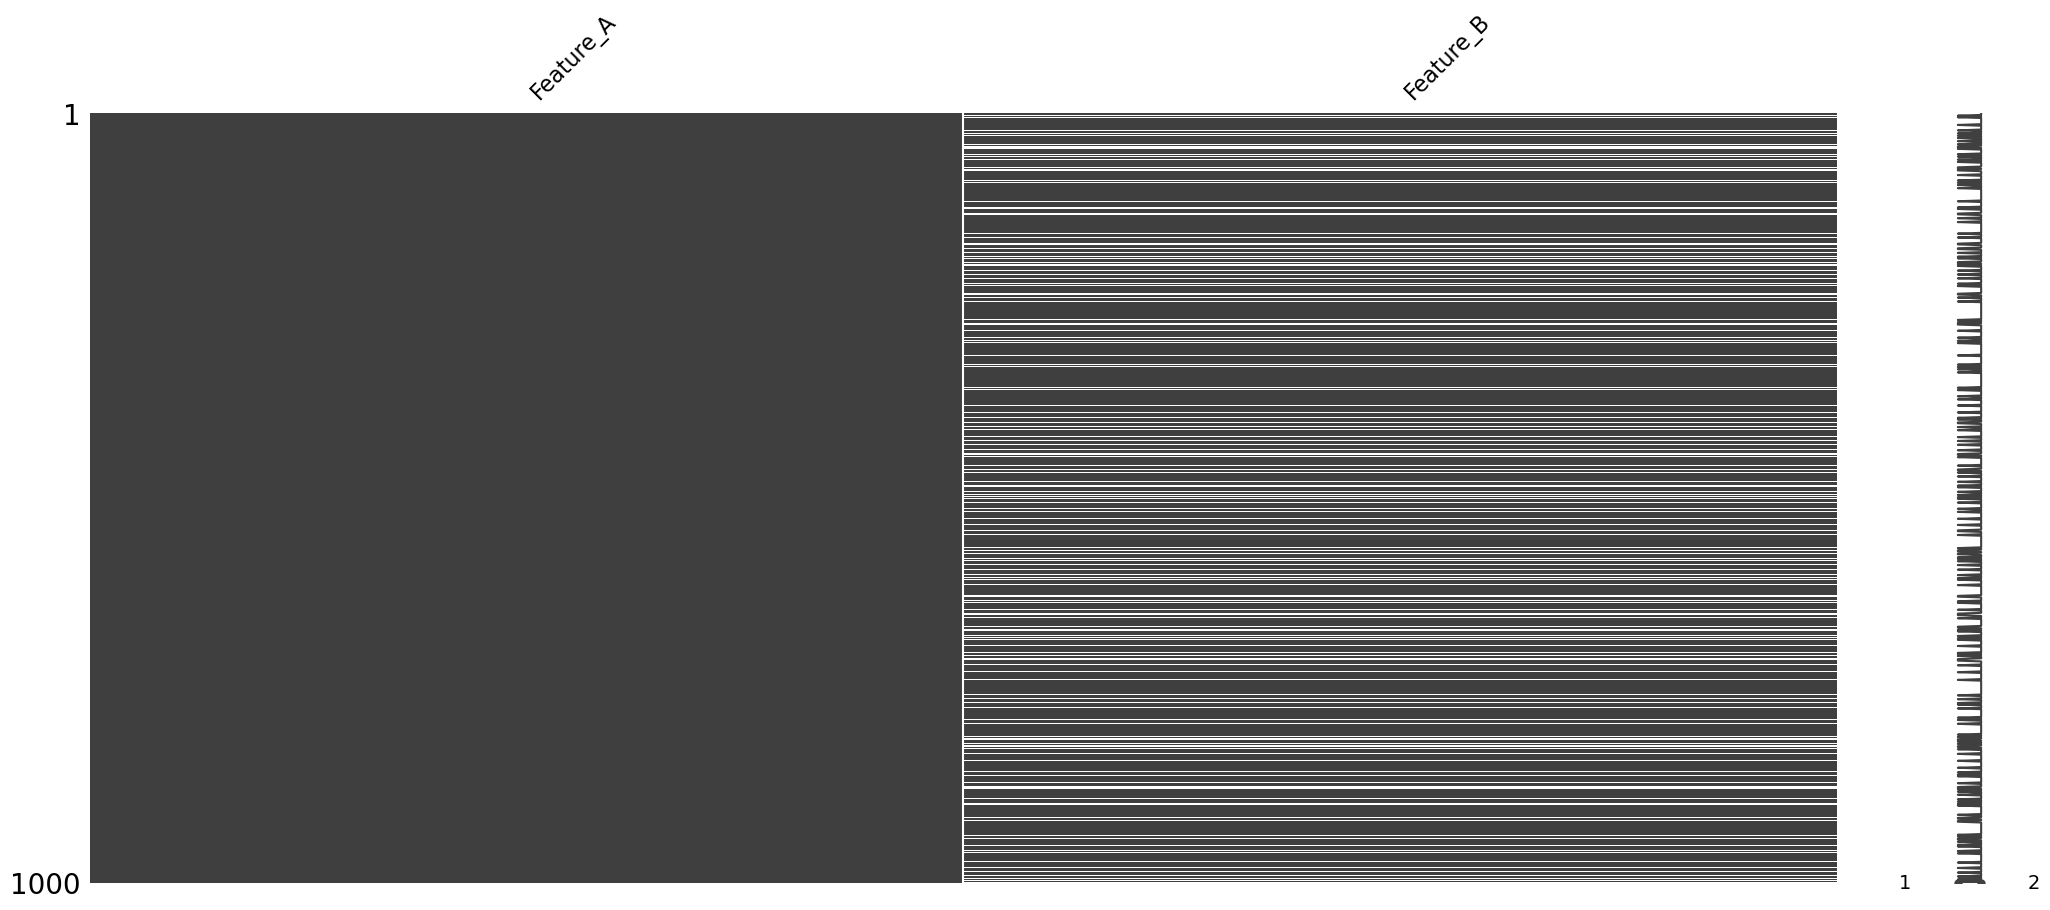

In [9]:
msno.matrix(df_miss_MCAR)

<Axes: >

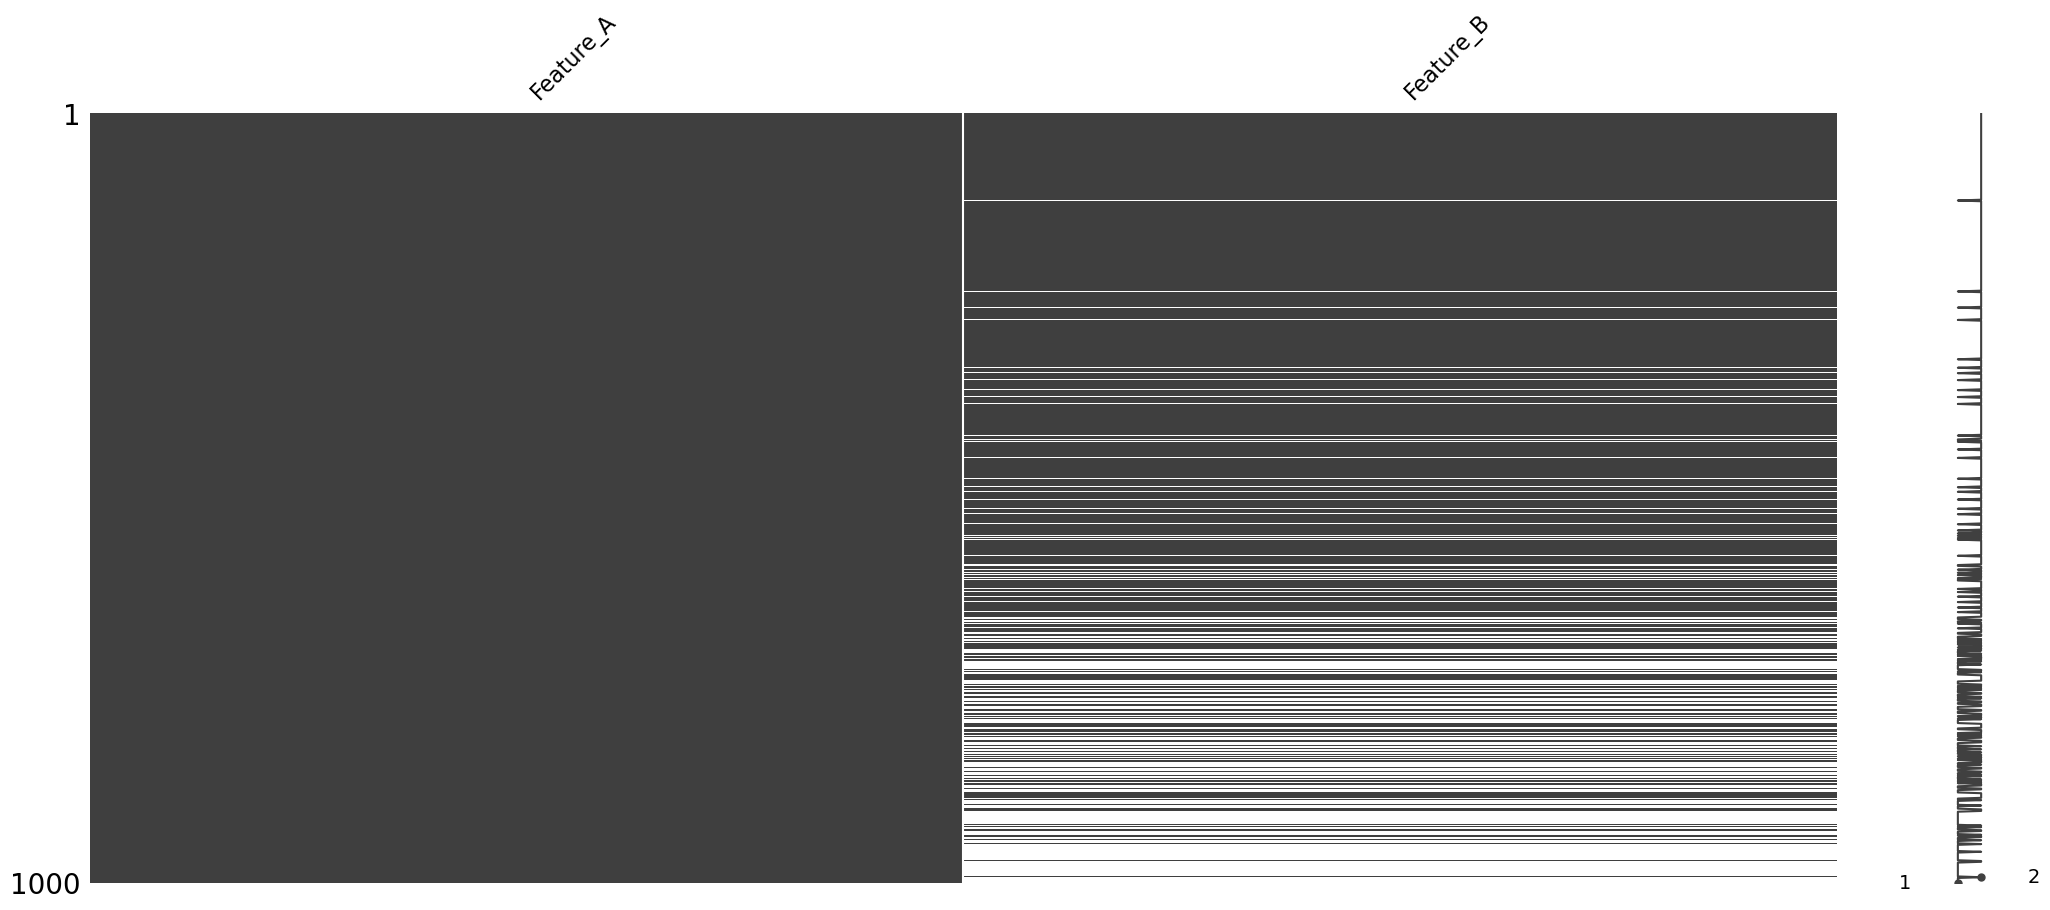

In [10]:
msno.matrix(df_miss_MAR)

In [20]:
np.random.seed(42)
n = 1000

age        = np.random.normal(40, 10, n)
experience = np.clip(age - 22 + np.random.normal(0, 3, n), 0, 40)
income     = 30000 + age * 1000 + experience * 500 + np.random.normal(0, 5000, n)
savings    = income * 0.2 + np.random.normal(0, 3000, n)
debt       = np.random.normal(15000, 5000, n)

df = pd.DataFrame({
    'Age':        age,
    'Experience': experience,
    'Income':     income,
    'Savings':    savings,
    'Debt':       debt
})

# --- MCAR — Income: purely random, independent ---
mcar_idx = np.random.choice(n, round(n * 0.2), replace=False)
df.iloc[mcar_idx, df.columns.get_loc('Income')] = np.nan

# --- MAR group — Income AND Savings AND Experience missing TOGETHER ---
# when Age > 50, all three go missing at the same rows
# msno.heatmap will show HIGH correlation between these three
age_over_50      = age > 50
group_candidates = np.where(age_over_50)[0]
group_idx        = np.random.choice(
                        group_candidates,
                        round(len(group_candidates) * 0.5),
                        replace=False
                   )
df.iloc[group_idx, df.columns.get_loc('Savings')]    = np.nan
df.iloc[group_idx, df.columns.get_loc('Experience')] = np.nan
df.iloc[group_idx, df.columns.get_loc('Debt')]       = np.nan

print("Missing per column:")
print(df.isnull().mean().round(3))

Missing per column:
Age           0.000
Experience    0.078
Income        0.200
Savings       0.078
Debt          0.078
dtype: float64


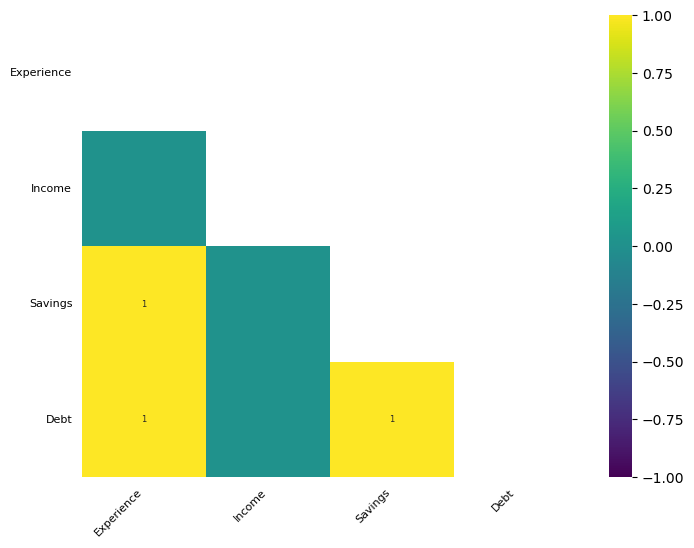

In [13]:
# correlation of missingness bw columns
msno.heatmap(df, figsize=(8,6), cmap="viridis", fontsize=8);

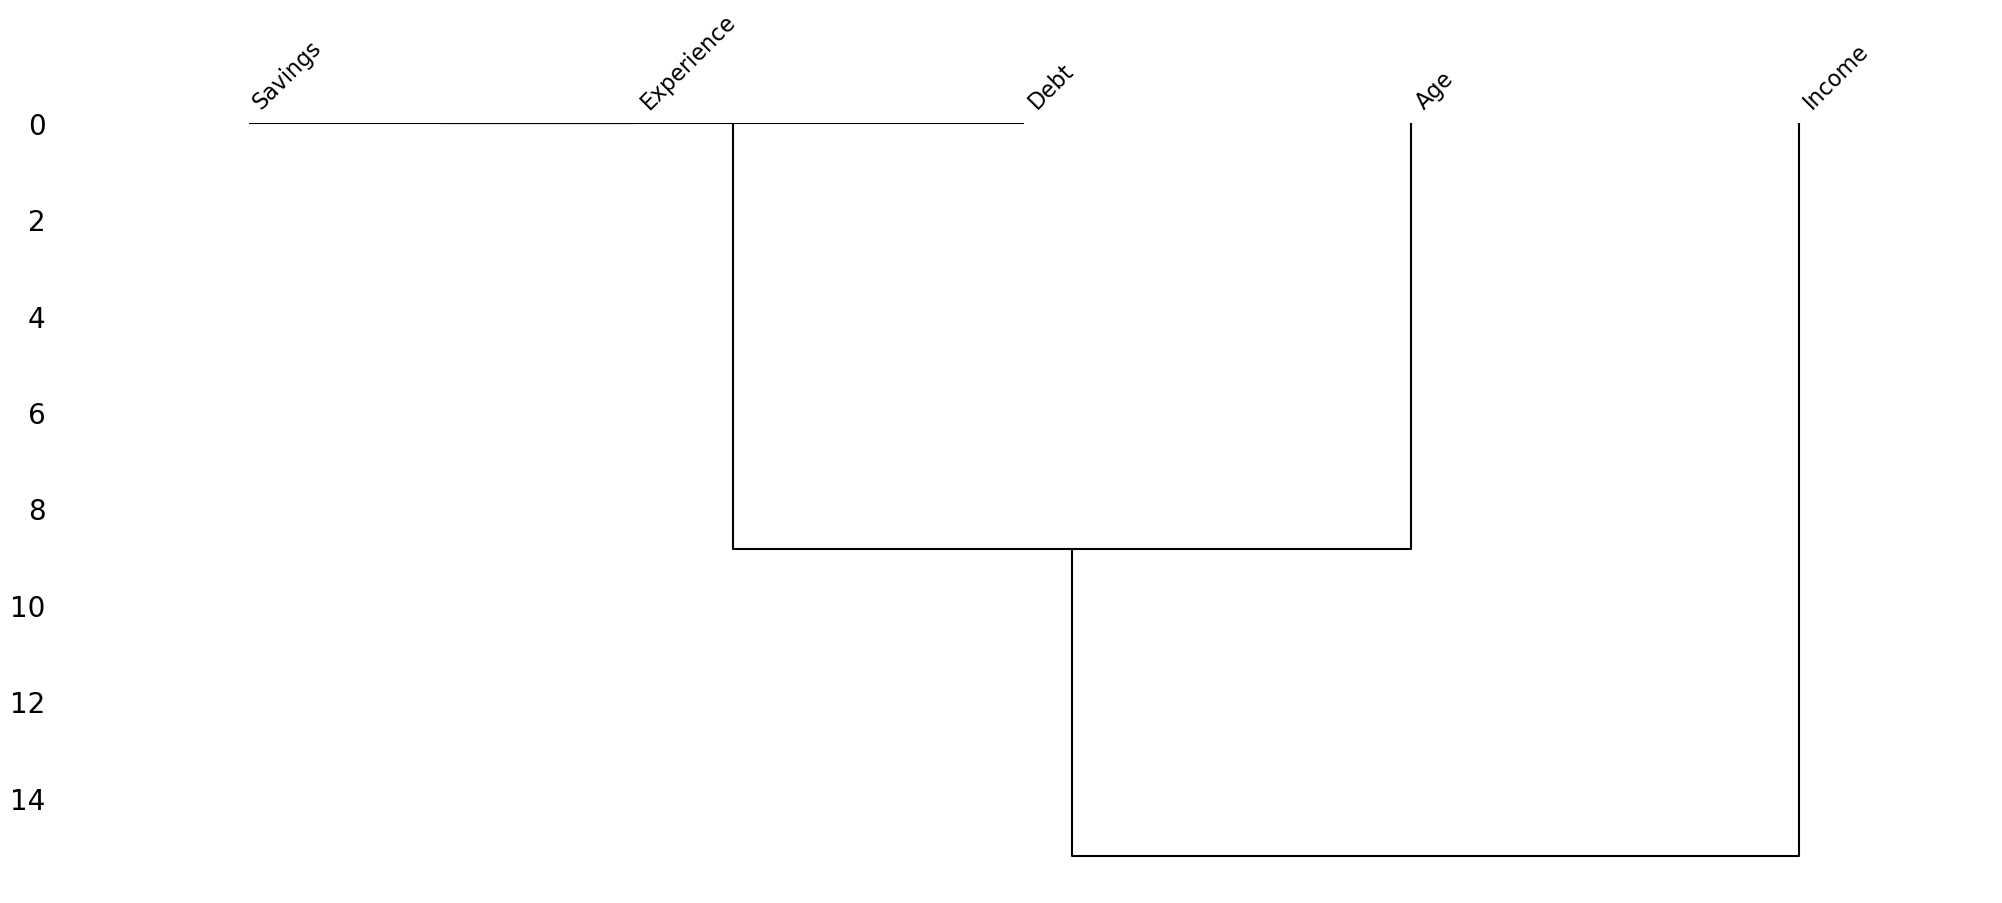

In [12]:
# columns which have missing value together cluster together
msno.dendrogram(df);

In [ ]:
"""
High correlation (r > 0.3)  →  Experience, Savings, Debt  →  MAR group 
low  correlation (r ≈ 0.0)  →  Income                     →  MCAR 
"""

In [ ]:
"""
create missing indicator columns (1 = missing, 0 = present)
this additional column helps for further statistical testing / ML models
"""

In [26]:
cols_with_missing = df.columns[df.isnull().any()].tolist()

for col in cols_with_missing:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

print(df[display_cols].head(10).to_string())

   Experience  Experience_missing         Income  Income_missing       Savings  Savings_missing          Debt  Debt_missing
0   27.165208                   0   85173.854075               0  11311.348141                0  10682.531975             0
1   19.391258                   0            NaN               1  12936.923498                0  14843.982555             0
2   24.655776                   0            NaN               1  15727.718204                0  15090.084360             0
3   31.289488                   0            NaN               1  25530.109978                0  17363.151729             0
4   17.753136                   0            NaN               1  15083.051577                0   8165.708184             0
5   16.839087                   0   77144.642261               0  11422.483745                0  17962.836369             0
6   36.477708                   0  104037.009439               0  22265.510756                0   1478.041842             0
7   27.5

In [ ]:
"""
numeric data
"""

/var/folders/_5/y4j884ds52508czqk75s5n8w0000gn/T/ipykernel_2243/2232021087.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([age_where_income_present, age_where_income_missing],


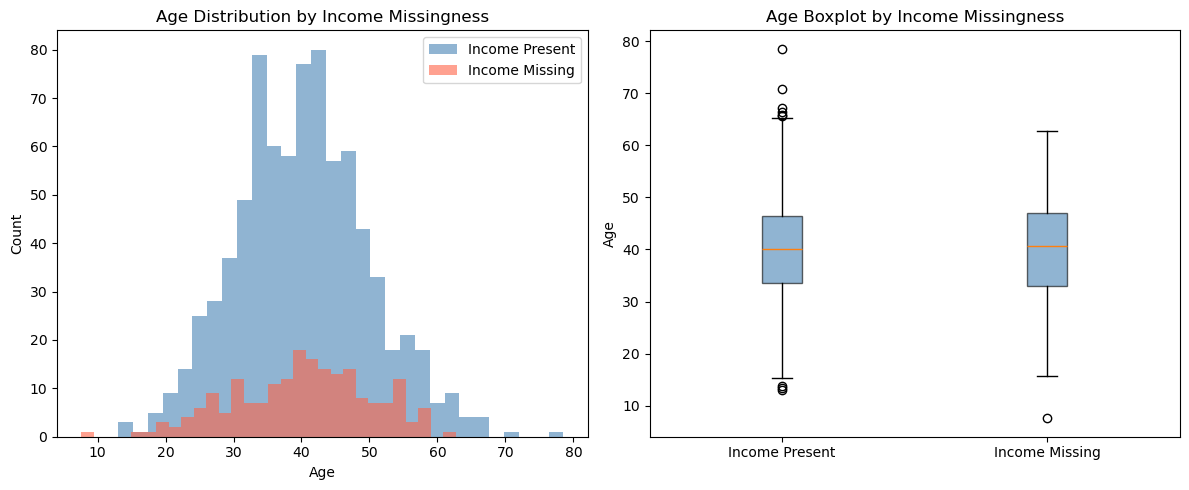

In [32]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

age_where_income_missing = df.loc[df['Income_missing'] == 1, 'Age']
age_where_income_present = df.loc[df['Income_missing'] == 0, 'Age']

# Histogram
ax1.hist(age_where_income_present, bins=30, alpha=0.6, label='Income Present', color='steelblue')
ax1.hist(age_where_income_missing, bins=30, alpha=0.6, label='Income Missing',  color='tomato')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.set_title('Age Distribution by Income Missingness')
ax1.legend()

# Boxplot
ax2.boxplot([age_where_income_present, age_where_income_missing],
            labels=['Income Present', 'Income Missing'],
            patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
ax2.set_ylabel('Age')
ax2.set_title('Age Boxplot by Income Missingness')

plt.tight_layout()
plt.show()

In [ ]:
# there is no change in the distribution here -> MCAR
# if there was any distribution change, we can conclude that the missingness is MAR

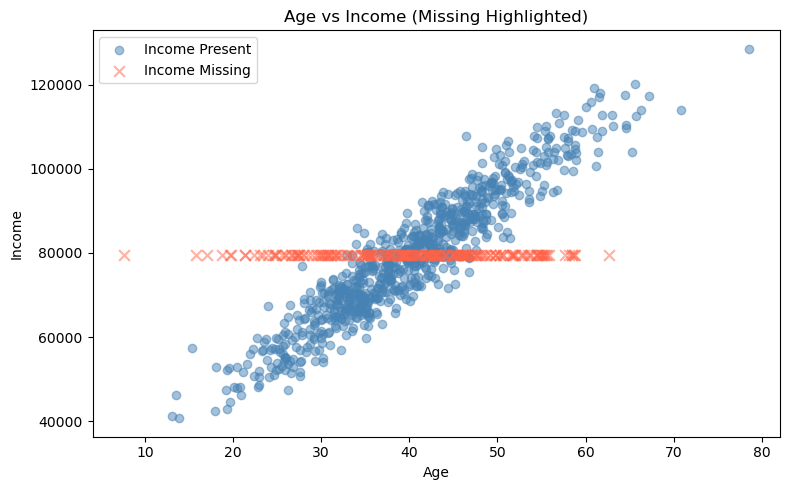

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

age_where_income_present = df.loc[df['Income_missing'] == 0, 'Age']
age_where_income_missing  = df.loc[df['Income_missing'] == 1, 'Age']

income_where_income_present = df.loc[df['Income_missing'] == 0, 'Income']

ax.scatter(age_where_income_present, income_where_income_present,
           alpha=0.5, color='steelblue', label='Income Present')

ax.scatter(age_where_income_missing, [df['Income'].mean()] * len(age_where_income_missing),
           alpha=0.5, color='tomato', marker='x', s=60, label='Income Missing')

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Age vs Income (Missing Highlighted)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# similarly a boxplot would reveal the same information
# in these plots, if the missingness occurs more at the extremes, we can suspect MNAR

In [ ]:
"""
for categorical and time series data, the experiments are pretty much same wrt the plots and nullity correlation matrix

categorical - 
check the missingness percentages
if the missing rates are similar, we can say that its MCAR
if the missing rates are not same, we can suspect MAR

further we can do chi square test
if the p value is less than 0.05, we can say in 95% confidence that the missingness is related to those variables
"""

In [39]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

gender     = np.random.choice(['Male', 'Female'], n)
education  = np.random.choice(['High School', 'Bachelor', 'Master'], n)
job_type   = np.random.choice(['Blue Collar', 'White Collar', 'Self Employed'], n)

df_cat = pd.DataFrame({
    'Gender':    gender,
    'Education': education,
    'Job_Type':  job_type
})

# MAR — Job_Type missing more often for 'Male' + 'High School'
missing_mask = (
    (df_cat['Gender'] == 'Male') & 
    (df_cat['Education'] == 'High School') & 
    (np.random.rand(n) < 0.6)
)

df_cat.loc[missing_mask, 'Job_Type'] = np.nan
df_cat['Job_Type_missing'] = df_cat['Job_Type'].isnull().astype(int)

print(df_cat['Job_Type'].isnull().mean().round(3))
print(df_cat.head())

0.103
   Gender    Education     Job_Type  Job_Type_missing
0    Male     Bachelor  Blue Collar                 0
1  Female       Master  Blue Collar                 0
2    Male  High School          NaN                 1
3    Male  High School          NaN                 1
4    Male  High School  Blue Collar                 0


In [43]:
from scipy.stats import chi2_contingency

cols_to_test = ['Gender', 'Education']

for col in cols_to_test:
    crosstab = pd.crosstab(df_cat[col], df_cat['Job_Type_missing'])
    chi2, p_val, dof, expected = chi2_contingency(crosstab)
    
    print(f"\n{col} vs Job_Type_missing\n")
    print(crosstab)
    print(f"chi2={chi2:.3f}  dof={dof}  p={p_val:.4f}\n", )
    print("MAR suspected" if p_val < 0.05 else "MCAR possible")


Gender vs Job_Type_missing

Job_Type_missing    0    1
Gender                    
Female            510    0
Male              387  103
chi2=117.250  dof=1  p=0.0000

MAR suspected

Education vs Job_Type_missing

Job_Type_missing    0    1
Education                 
Bachelor          331    0
High School       238  103
Master            328    0
chi2=221.909  dof=2  p=0.0000

MAR suspected


In [ ]:
"""
time series - 

extract the seasonality and check the missing rates, see if the missingness is at particular season (time of the day, day of the week etc)
plot the time differences in the series and plot the histogram to see if there are suspiciously long silences in this data
"""

In [46]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 8760  # one full year of hourly data

timestamps = pd.date_range(start='2023-01-01', periods=n, freq='h')
temperature = np.random.normal(25, 5, n)

df_ts = pd.DataFrame({'timestamp': timestamps, 'temperature': temperature})

# extract the seasonality using the pandas dt
df_ts['hour']    = df_ts['timestamp'].dt.hour
df_ts['weekday'] = df_ts['timestamp'].dt.day_name()
df_ts['month']   = df_ts['timestamp'].dt.month_name()

# MAR — temperature missing mostly at night (10pm to 5am)
night_mask = df_ts['hour'].between(22, 23) | df_ts['hour'].between(0, 5)
missing_mask = night_mask & (np.random.rand(n) < 0.6)

df_ts.loc[missing_mask, 'temperature'] = np.nan
df_ts['temperature_missing'] = df_ts['temperature'].isnull().astype(int)

print(df_ts.head())

            timestamp  temperature  hour weekday    month  temperature_missing
0 2023-01-01 00:00:00          NaN     0  Sunday  January                    1
1 2023-01-01 01:00:00    24.308678     1  Sunday  January                    0
2 2023-01-01 02:00:00    28.238443     2  Sunday  January                    0
3 2023-01-01 03:00:00          NaN     3  Sunday  January                    1
4 2023-01-01 04:00:00          NaN     4  Sunday  January                    1


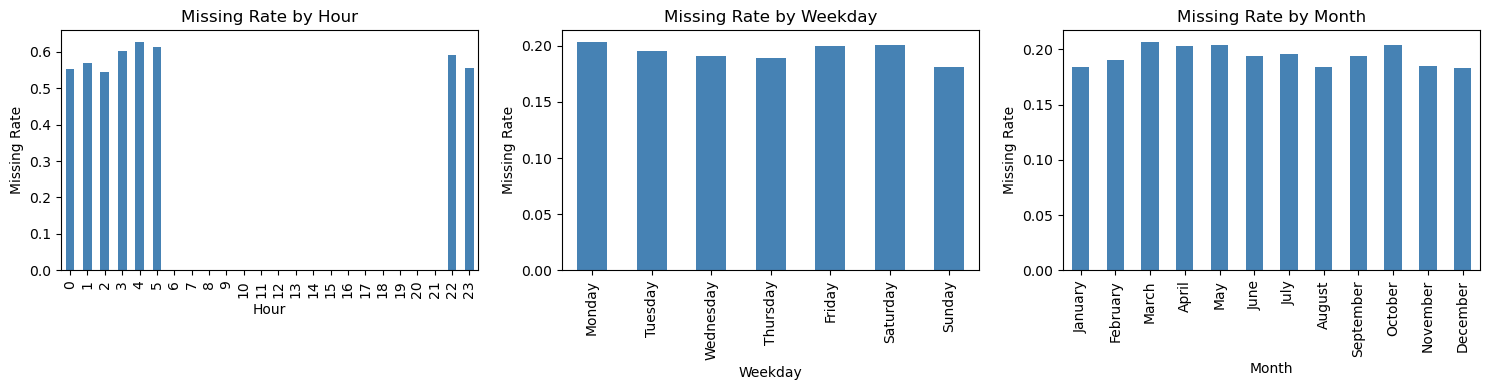

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# by hour
df_ts.groupby('hour')['temperature_missing'].mean().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Missing Rate by Hour')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Missing Rate')

# by weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_ts.groupby('weekday')['temperature_missing'].mean().reindex(weekday_order).plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Missing Rate by Weekday')
ax2.set_xlabel('Weekday')
ax2.set_ylabel('Missing Rate')

# by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_ts.groupby('month')['temperature_missing'].mean().reindex(month_order).plot(kind='bar', ax=ax3, color='steelblue')
ax3.set_title('Missing Rate by Month')
ax3.set_xlabel('Month')
ax3.set_ylabel('Missing Rate')

plt.tight_layout()
plt.show()

In [53]:
import pandas as pd
import numpy as np

np.random.seed(42)

# irregular sensor logs — readings come randomly, not every hour
n = 500
start = pd.Timestamp('2023-01-01')

# random irregular intervals between 1 min and 3 hours
random_intervals = np.random.exponential(scale=30, size=n)  # avg 30 min gap
timestamps = start + pd.to_timedelta(np.cumsum(random_intervals), unit='min')

temperature = np.random.normal(22, 4, n)

df_sensor = pd.DataFrame({'timestamp': timestamps, 'temperature': temperature})

# MAR — sensor shuts down at night (10pm to 6am), causing LARGE gaps
night_hours = df_sensor['timestamp'].dt.hour.between(22, 23) | df_sensor['timestamp'].dt.hour.between(0, 6)
df_sensor.loc[night_hours, 'temperature'] = np.nan
df_sensor['temperature_missing'] = df_sensor['temperature'].isnull().astype(int)

df_sensor['time_diff_minutes'] = df_sensor['timestamp'].diff().dt.total_seconds() / 60

                      timestamp  temperature  temperature_missing  time_diff_minutes
0 2023-01-01 00:14:04.682561958          NaN                    1                NaN
1 2023-01-01 01:44:22.901137608          NaN                    1          90.303643
2 2023-01-01 02:23:53.043385992          NaN                    1          39.502371
3 2023-01-01 02:51:16.339982790          NaN                    1          27.388277
4 2023-01-01 02:56:21.664749618          NaN                    1           5.088746
5 2023-01-01 03:01:26.938075068          NaN                    1           5.087889
6 2023-01-01 03:03:14.647858560          NaN                    1           1.795163
7 2023-01-01 04:03:34.863414624          NaN                    1          60.336926
8 2023-01-01 04:31:09.211291158          NaN                    1          27.572465
9 2023-01-01 05:08:05.461402224          NaN                    1          36.937502


In [63]:
df_sensor.head(10)

,timestamp,temperature,temperature_missing,time_diff_minutes
0,2023-01-01 00:14:04.682561958,NaN,1,NaN
1,2023-01-01 01:44:22.901137608,NaN,1,90.303643
2,2023-01-01 02:23:53.043385992,NaN,1,39.502371
3,2023-01-01 02:51:16.339982790,NaN,1,27.388277
4,2023-01-01 02:56:21.664749618,NaN,1,5.088746
5,2023-01-01 03:01:26.938075068,NaN,1,5.087889
6,2023-01-01 03:03:14.647858560,NaN,1,1.795163
7,2023-01-01 04:03:34.863414624,NaN,1,60.336926
8,2023-01-01 04:31:09.211291158,NaN,1,27.572465
9,2023-01-01 05:08:05.461402224,NaN,1,36.937502


<Axes: >

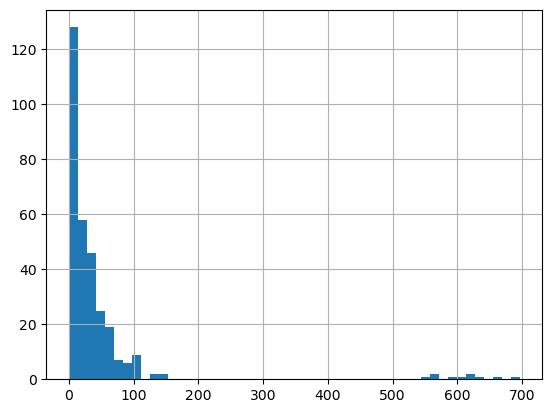

In [61]:
# only keep rows where sensor actually logged something
df_sensor_logged = df_sensor.dropna(subset=['temperature']).copy()
df_sensor_logged['time_diff_minutes'] = df_sensor_logged['timestamp'].diff().dt.total_seconds() / 60

# now large gaps = periods where sensor was silent
df_sensor_logged['time_diff_minutes'].hist(bins=50)